In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")

df.head()
df.describe()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Handle Missing Values

In [3]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns      # include=["float64"],include=["int64"] , number=float+int+other numeric types

In [4]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

# If some integer/floats are of object type , then convert into num using
# for col in df.columns:
    # df[col] = pd.to_numeric(df[col], errors='ignore')

df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [5]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

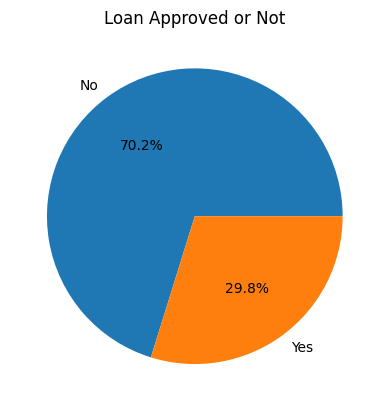

In [6]:
# How balanced our classes are?
class_counts=df["Loan_Approved"].value_counts()

plt.pie(class_counts , autopct="%1.1f%%" , labels=["No","Yes"])
plt.title("Loan Approved or Not")

class_counts

Text(0.5, 0, 'Loan Purpose')

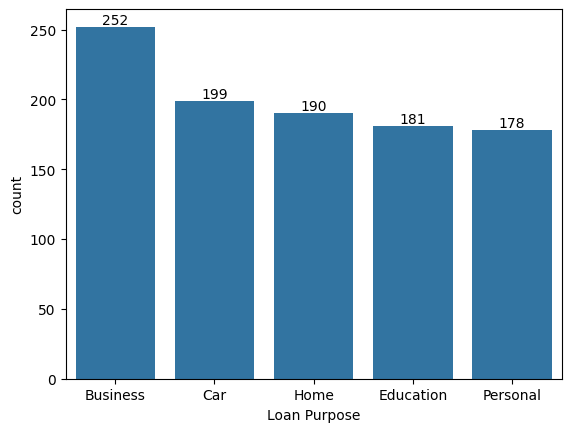

In [7]:
# Categories
# 1. Gender
# gender_count = df["Gender"].value_counts()
# ax = sns.barplot(gender_count)
# ax.bar_label(ax.containers[0])

# 2. Loan Purpose
loan_purpose_cnt = df["Loan_Purpose"].value_counts()
ax = sns.barplot(loan_purpose_cnt)
ax.bar_label(ax.containers[0])
plt.xlabel("Loan Purpose")



<Axes: xlabel='Applicant_Income', ylabel='Count'>

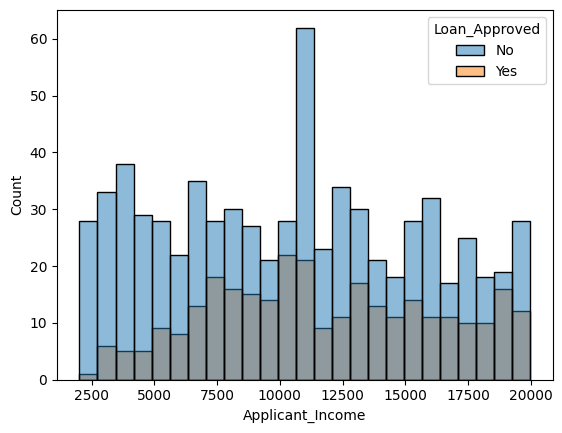

In [8]:
# Analyze Income
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=25,
    hue="Loan_Approved",
    # multiple="dodge"
)

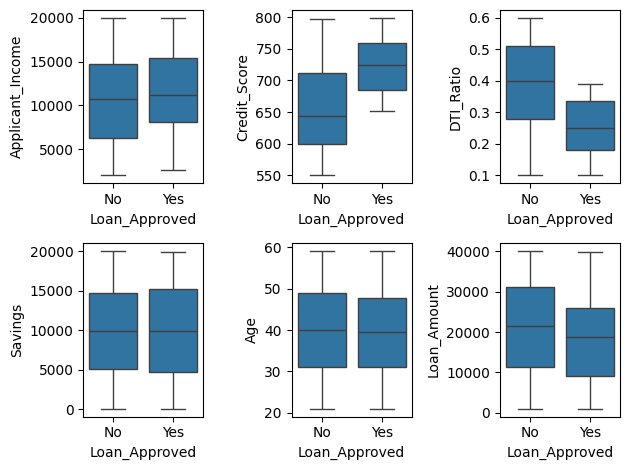

In [9]:
# Check for outliers in income
fig,axes = plt.subplots(2,3)

sns.boxplot(ax = axes[0][0] , data=df , x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax = axes[0][1] , data=df , x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax = axes[0][2] , data=df , x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax = axes[1][0] , data=df , x="Loan_Approved",y="Savings")
sns.boxplot(ax = axes[1][1] , data=df , x="Loan_Approved",y="Age")
sns.boxplot(ax = axes[1][2] , data=df , x="Loan_Approved",y="Loan_Amount")

fig.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

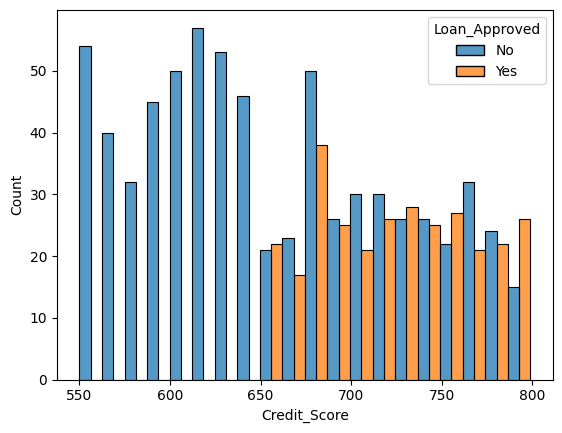

In [10]:
# Credit Score vs Loan Approved
sns.histplot(
    data=df,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)
# Loans are approved when credit score>650 . High credit score , more the chance of getting loan - PATTERN

In [11]:
# Removing Applicant ID
df = df.drop(columns=["Applicant_ID"])
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Encoding

In [12]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [13]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [14]:
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [15]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [16]:
cols=["Employment_Status",'Marital_Status','Loan_Purpose', 'Property_Area','Gender', 'Employer_Category']

ohe=OneHotEncoder(drop="first",sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])  # encoded is in form of 2D array
encoded_df = pd.DataFrame(encoded, columns= ohe.get_feature_names_out(cols) , index = df.index)

df = pd.concat([df.drop(columns=cols) , encoded_df] , axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation HeatMap

In [18]:
num_cols=df.select_dtypes(include=["number"])
corr_matrix = num_cols.corr()

In [19]:
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

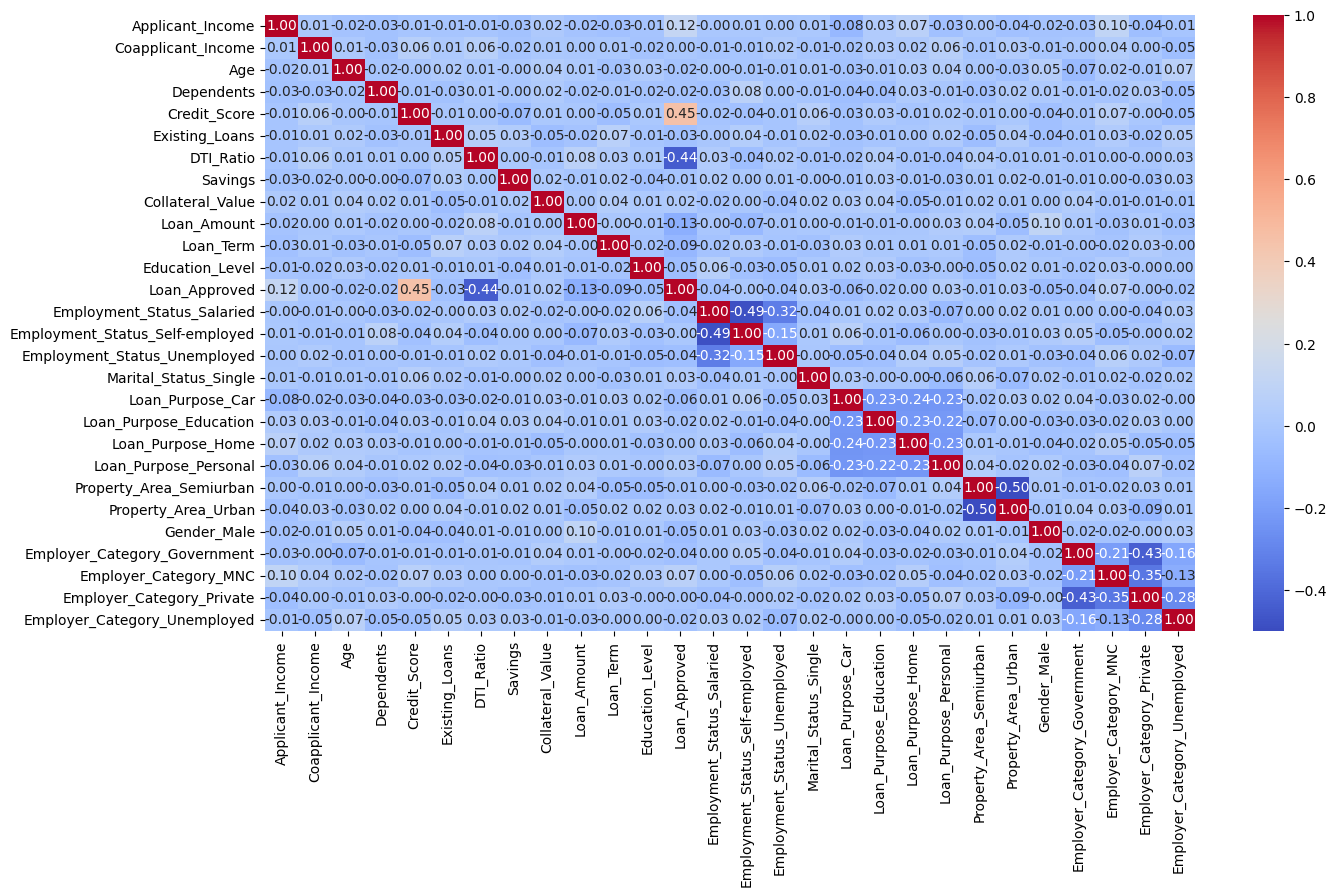

In [20]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    fmt=".2f",
    annot=True,
    cmap="coolwarm"
)

# Train-Test-Split + Feature Scaling

In [21]:
X = df.drop(columns=["Loan_Approved"])
y = df["Loan_Approved"]

In [22]:
X_train , X_test , y_train , y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [24]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]],
      shape=(800, 27))

# Train & Evaluate Models

In [25]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , f1_score,recall_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled , y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Logistic Regression")
print("Precision=" , precision_score(y_test , y_pred) * 100)
print("Recall=" , recall_score(y_test , y_pred) * 100)
print("f1=" , f1_score(y_test , y_pred) * 100)
print("Accuracy=" , accuracy_score(y_test , y_pred) * 100)
print("Confusion Matrix:" , confusion_matrix(y_test , y_pred))


Logistic Regression
Precision= 78.33333333333333
Recall= 77.04918032786885
f1= 77.68595041322314
Accuracy= 86.5
Confusion Matrix: [[126  13]
 [ 14  47]]


In [26]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , f1_score,recall_score

knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

#Evaluation
print("KNN")
print("Precision=" , precision_score(y_test , y_pred) * 100)
print("Recall=" , recall_score(y_test , y_pred) * 100)
print("f1=" , f1_score(y_test , y_pred) * 100)
print("Accuracy=" , accuracy_score(y_test , y_pred) * 100)
print("Confusion Matrix:" , confusion_matrix(y_test , y_pred))

KNN
Precision= 65.85365853658537
Recall= 44.26229508196721
f1= 52.94117647058824
Accuracy= 76.0
Confusion Matrix: [[125  14]
 [ 34  27]]


In [27]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , f1_score,recall_score

nb_model = GaussianNB()
nb_model.fit(X_train_scaled , y_train)

y_pred = nb_model.predict(X_test_scaled)

#Evaluation
print("KNN")
print("Precision=" , precision_score(y_test , y_pred) * 100)
print("Recall=" , recall_score(y_test , y_pred) * 100)
print("f1=" , f1_score(y_test , y_pred) * 100)
print("Accuracy=" , accuracy_score(y_test , y_pred) * 100)
print("Confusion Matrix:" , confusion_matrix(y_test , y_pred))

KNN
Precision= 80.35714285714286
Recall= 73.77049180327869
f1= 76.92307692307693
Accuracy= 86.5
Confusion Matrix: [[128  11]
 [ 16  45]]


# Feature Engineering

In [28]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

X = df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y = df["Loan_Approved"]

X_train , X_test , y_train , y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

                            Feature  Coefficient
26                  Credit_Score_sq     1.821872
0                  Applicant_Income     0.475940
22            Employer_Category_MNC     0.197565
24     Employer_Category_Unemployed     0.119738
19              Property_Area_Urban     0.110950
23        Employer_Category_Private     0.097952
5                           Savings     0.045461
13            Marital_Status_Single     0.043335
4                    Existing_Loans     0.028241
1                Coapplicant_Income     0.013891
6                  Collateral_Value    -0.009438
18          Property_Area_Semiurban    -0.022506
2                               Age    -0.022649
21     Employer_Category_Government    -0.024055
17            Loan_Purpose_Personal    -0.068118
3                        Dependents    -0.114367
11  Employment_Status_Self-employed    -0.150917
8                         Loan_Term    -0.154729
9                   Education_Level    -0.166172
16                Lo

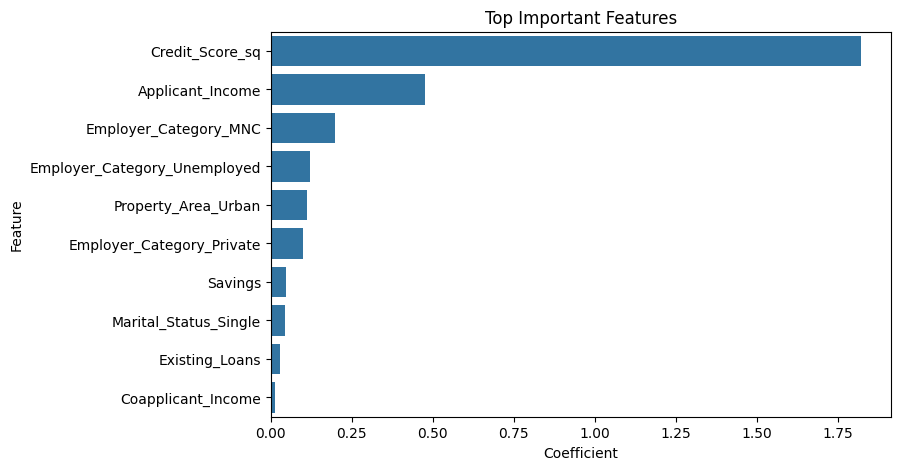

In [29]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , f1_score,recall_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled , y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(10))
plt.title("Top Important Features")

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.7).astype(int)
# y_pred = log_model.predict(X_test_scaled) By adding above 2 lines , precision went from 79 to 90

#Evaluation
print("Logistic Regression")
print("Precision=" , precision_score(y_test , y_pred) * 100)
print("Recall=" , recall_score(y_test , y_pred) * 100)
print("f1=" , f1_score(y_test , y_pred) * 100)
print("Accuracy=" , accuracy_score(y_test , y_pred) * 100)
print("Confusion Matrix:" , confusion_matrix(y_test , y_pred))

In [30]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , f1_score,recall_score

knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

#Evaluation
print("KNN")
print("Precision=" , precision_score(y_test , y_pred) * 100)
print("Recall=" , recall_score(y_test , y_pred) * 100)
print("f1=" , f1_score(y_test , y_pred) * 100)
print("Accuracy=" , accuracy_score(y_test , y_pred) * 100)
print("Confusion Matrix:" , confusion_matrix(y_test , y_pred))

KNN
Precision= 66.66666666666666
Recall= 49.18032786885246
f1= 56.60377358490566
Accuracy= 77.0
Confusion Matrix: [[124  15]
 [ 31  30]]


In [31]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , f1_score,recall_score

nb_model = GaussianNB()
nb_model.fit(X_train_scaled , y_train)

y_pred = nb_model.predict(X_test_scaled)

#Evaluation
print("KNN")
print("Precision=" , precision_score(y_test , y_pred) * 100)
print("Recall=" , recall_score(y_test , y_pred) * 100)
print("f1=" , f1_score(y_test , y_pred) * 100)
print("Accuracy=" , accuracy_score(y_test , y_pred) * 100)
print("Confusion Matrix:" , confusion_matrix(y_test , y_pred))

KNN
Precision= 78.33333333333333
Recall= 77.04918032786885
f1= 77.68595041322314
Accuracy= 86.5
Confusion Matrix: [[126  13]
 [ 14  47]]


## Insights:  
### 1) Customers with higher credit score and lower debt-to-income ratio have a higher probability of loan approval.
### 2) Applicants with multiple existing loans show higher rejection rates.

## Business Requirement:
### Naive Bayes achieved higher recall, meaning it correctly identified more eligible customers.

### Logistic Regression achieved higher precision, reducing the number of incorrect loan approvals.

### Depending on business requirements:
#### - If minimizing risk is priority → Logistic Regression is preferred
#### - If maximizing approvals is priority → Naive Bayes is preferred